In [1]:
import random
import math
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import Dataset
from torchvision.datasets import CIFAR100
from transformers import CLIPModel, CLIPProcessor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print(f"Python version: {__import__('sys').version}")
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {__import__('transformers').__version__}")
print(f"Device: {device}")

Python version: 3.10.2 (tags/v3.10.2:a58ebcc, Jan 17 2022, 14:12:15) [MSC v.1929 64 bit (AMD64)]
PyTorch version: 2.11.0+cpu
Transformers version: 5.4.0
Device: cpu


In [2]:
SELECTED_CLASSES = [
    "apple", "bicycle", "bottle", "bowl", "bus", "butterfly",
    "chair", "clock", "keyboard", "lamp", "train", "turtle",
]

print("Downloading CIFAR-100 test set...")
cifar_test      = CIFAR100(root="./data", train=False, download=True)
all_class_names = cifar_test.classes

counts           = defaultdict(int)
selected_indices = []
for idx, (_, target) in enumerate(cifar_test):
    cname = all_class_names[target]
    if cname in set(SELECTED_CLASSES) and counts[cname] < 30:
        selected_indices.append(idx)
        counts[cname] += 1
    if all(counts[n] == 30 for n in SELECTED_CLASSES):
        break

print(f"Total selected images : {len(selected_indices)}")
print(f"Images per class      : {dict(counts)}")

100%|███████████████████████████████████████████████████████████████████████████████| 169M/169M [00:03<00:00, 54.5MB/s]


Total selected images : 360
Images per class      : {'apple': 30, 'butterfly': 30, 'lamp': 30, 'keyboard': 30, 'bicycle': 30, 'chair': 30, 'turtle': 30, 'clock': 30, 'bottle': 30, 'train': 30, 'bowl': 30, 'bus': 30}


In [3]:
class CIFARSubsetDataset(Dataset):
    def __init__(self, base_dataset, indices, selected_classes):
        self.base_dataset       = base_dataset
        self.indices            = indices
        self.selected_classes   = selected_classes
        self.all_class_names    = base_dataset.classes
        self.class_to_new_label = {n: i for i, n in enumerate(selected_classes)}

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        base_idx             = self.indices[idx]
        image, old_label     = self.base_dataset[base_idx]
        class_name           = self.all_class_names[old_label]
        new_label            = self.class_to_new_label[class_name]
        return image, new_label, class_name, base_idx

subset_dataset = CIFARSubsetDataset(cifar_test, selected_indices, SELECTED_CLASSES)

all_images, all_labels, all_example_class_names = [], [], []
for i in range(len(subset_dataset)):
    image, label, cname, _ = subset_dataset[i]
    all_images.append(image)
    all_labels.append(label)
    all_example_class_names.append(cname)

all_labels = np.array(all_labels)
print(f"Images loaded : {len(all_images)}")
print(f"Labels shape  : {all_labels.shape}")
print(f"Label range   : {all_labels.min()} to {all_labels.max()}")

Images loaded : 360
Labels shape  : (360,)
Label range   : 0 to 11


In [4]:
model_name = "openai/clip-vit-base-patch32"
processor  = CLIPProcessor.from_pretrained(model_name)
clip_model = CLIPModel.from_pretrained(model_name)
clip_model.to(device)
clip_model.eval()

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

C:\Users\vardh\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vardh\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [7]:
@torch.no_grad()
def encode_texts(texts, batch_size=32):
    feats = []
    for start in range(0, len(texts), batch_size):
        batch  = texts[start:start + batch_size]
        inputs = processor(text=batch, return_tensors="pt",
                           padding=True, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        tf     = clip_model.get_text_features(**inputs)
        # handle both tensor and model output object
        if hasattr(tf, 'pooler_output'):
            tf = tf.pooler_output
        tf = tf / tf.norm(dim=-1, keepdim=True)
        feats.append(tf.cpu())
    return torch.cat(feats, dim=0)


@torch.no_grad()
def encode_images(pil_images, batch_size=32):
    feats = []
    for start in range(0, len(pil_images), batch_size):
        batch  = pil_images[start:start + batch_size]
        inputs = processor(images=batch, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        imf    = clip_model.get_image_features(**inputs)
        # handle both tensor and model output object
        if hasattr(imf, 'pooler_output'):
            imf = imf.pooler_output
        imf = imf / imf.norm(dim=-1, keepdim=True)
        feats.append(imf.cpu())
    return torch.cat(feats, dim=0)

In [8]:
image_features = encode_images(all_images)
print(f"Image features shape: {image_features.shape}")

Image features shape: torch.Size([360, 512])


In [9]:
print("Q3.1 — Basic zero-shot (plain class names)")

text_feats_basic = encode_texts(SELECTED_CLASSES)
sim_basic        = image_features @ text_feats_basic.T
preds_basic      = sim_basic.argmax(dim=1).numpy()
acc_basic        = accuracy_score(all_labels, preds_basic) * 100

print(f"Basic zero-shot accuracy: {acc_basic:.2f}%")

Q3.1 — Basic zero-shot (plain class names)
Basic zero-shot accuracy: 91.11%


In [10]:
print("Q3.2 — Prompt-engineered zero-shot")


prompt_templates = [
    "a photo of a {}.",
    "a blurry photo of a {}.",
    "a black and white photo of a {}.",
    "a photo of the {}.",
    "a close-up photo of a {}.",
    "a bright photo of a {}.",
    "a cropped photo of a {}.",
]

prompted_feats = []
for cname in SELECTED_CLASSES:
    prompts = [t.format(cname) for t in prompt_templates]
    feats   = encode_texts(prompts)
    avg     = feats.mean(dim=0)
    avg     = avg / avg.norm()
    prompted_feats.append(avg)

prompted_feats = torch.stack(prompted_feats, dim=0)
sim_prompted   = image_features @ prompted_feats.T
preds_prompted = sim_prompted.argmax(dim=1).numpy()
acc_prompted   = accuracy_score(all_labels, preds_prompted) * 100

print(f"Basic accuracy    : {acc_basic:.2f}%")
print(f"Prompted accuracy : {acc_prompted:.2f}%")
print(f"Improvement       : +{acc_prompted - acc_basic:.2f}%")

Q3.2 — Prompt-engineered zero-shot
Basic accuracy    : 91.11%
Prompted accuracy : 92.50%
Improvement       : +1.39%


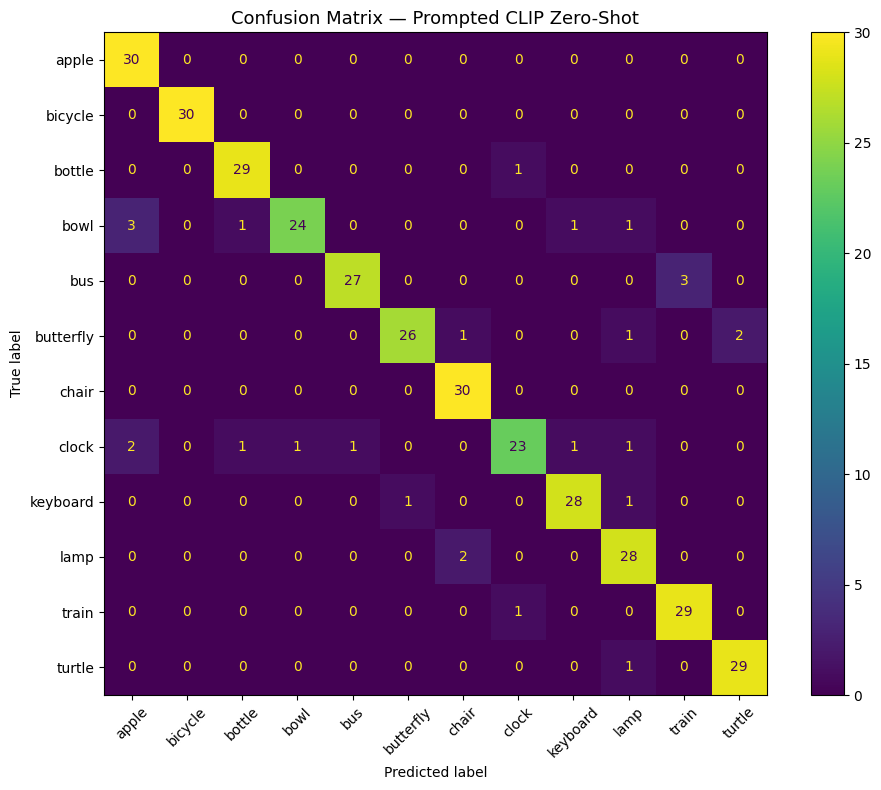

Most confused: 'bowl' predicted as 'apple' (3 times)


In [11]:
cm = confusion_matrix(all_labels, preds_prompted)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=SELECTED_CLASSES)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
ax.set_title("Confusion Matrix — Prompted CLIP Zero-Shot", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
i, j = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
print(f"Most confused: '{SELECTED_CLASSES[i]}' predicted as "
      f"'{SELECTED_CLASSES[j]}' ({cm_no_diag[i,j]} times)")

In [12]:
def retrieve_images(query, image_features, top_k=5):
    query_feat  = encode_texts([query])
    sims        = (image_features @ query_feat.T).squeeze(1)
    top_indices = sims.argsort(descending=True)[:top_k].tolist()
    scores      = sims[top_indices].tolist()
    return top_indices, scores


def show_retrieval_results(query, top_indices, scores, images, class_names):
    fig, axes = plt.subplots(1, len(top_indices), figsize=(15, 3))
    for rank, (idx, score) in enumerate(zip(top_indices, scores), start=1):
        axes[rank-1].imshow(images[idx])
        axes[rank-1].set_title(f"#{rank} {class_names[idx]}\n{score:.3f}", fontsize=9)
        axes[rank-1].axis("off")
    fig.suptitle(f'Query: "{query}"', fontsize=11, y=1.02)
    plt.tight_layout()
    fname = f"retrieval_{query[:15].replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")


Query: 'a yellow school bus'
  #1: bus          score=0.3081
  #2: bus          score=0.3013
  #3: bus          score=0.2987
  #4: bus          score=0.2910
  #5: bus          score=0.2712


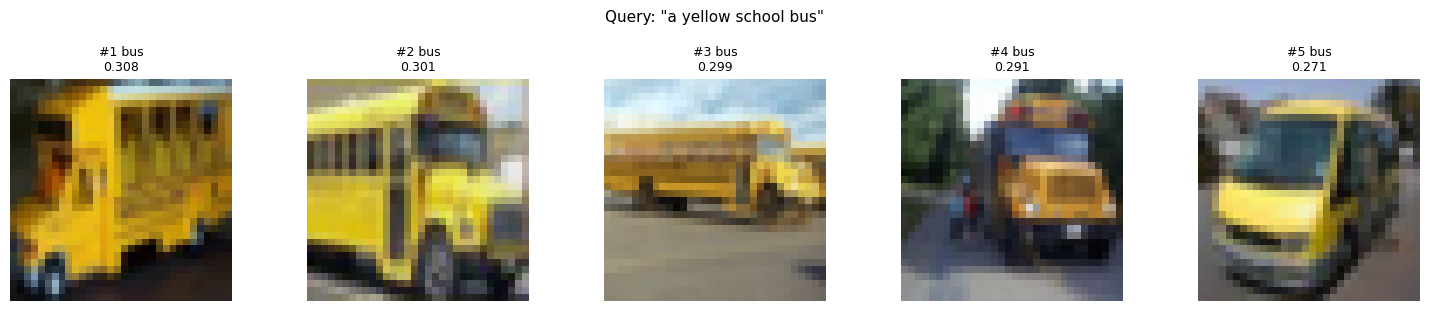

Saved: retrieval_a_yellow_school.png

Query: 'a flying butterfly'
  #1: butterfly    score=0.2908
  #2: butterfly    score=0.2893
  #3: butterfly    score=0.2791
  #4: butterfly    score=0.2785
  #5: butterfly    score=0.2772


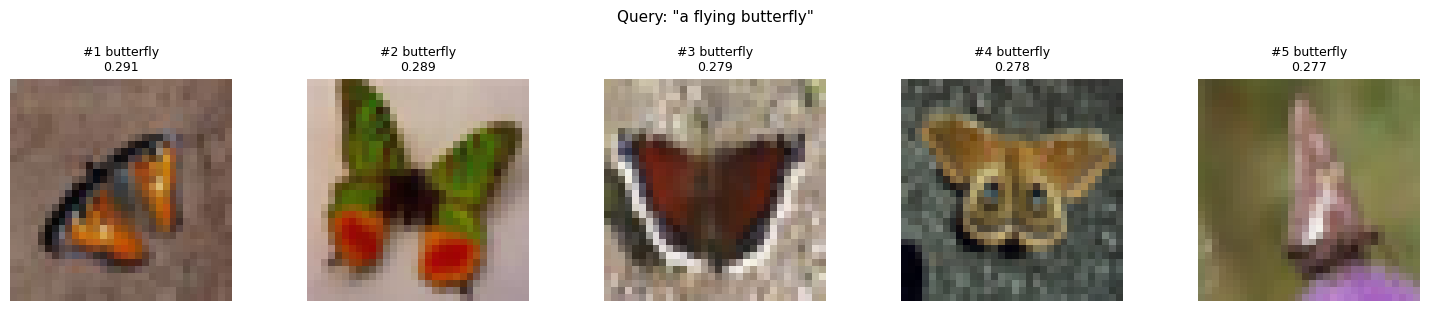

Saved: retrieval_a_flying_butter.png

Query: 'a desk lamp'
  #1: lamp         score=0.2884
  #2: lamp         score=0.2872
  #3: lamp         score=0.2853
  #4: lamp         score=0.2842
  #5: lamp         score=0.2817


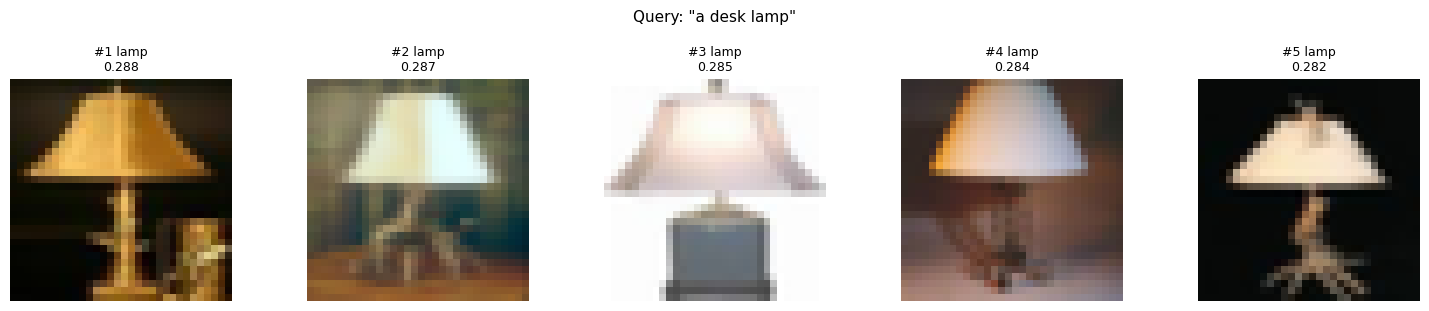

Saved: retrieval_a_desk_lamp.png

Query: 'a turtle swimming'
  #1: turtle       score=0.2859
  #2: turtle       score=0.2832
  #3: turtle       score=0.2823
  #4: turtle       score=0.2737
  #5: turtle       score=0.2732


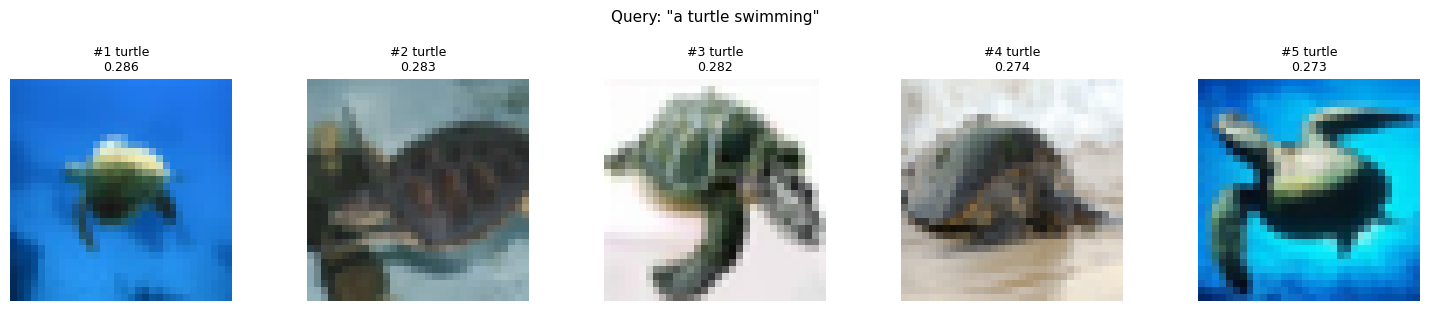

Saved: retrieval_a_turtle_swimmi.png


In [13]:
queries = [
    "a yellow school bus",
    "a flying butterfly",
    "a desk lamp",
    "a turtle swimming",
]

for query in queries:
    top_indices, scores = retrieve_images(query, image_features, top_k=5)
    print(f"\nQuery: '{query}'")
    for rank, (idx, score) in enumerate(zip(top_indices, scores), start=1):
        print(f"  #{rank}: {all_example_class_names[idx]:<12} score={score:.4f}")
    show_retrieval_results(query, top_indices, scores,
                            all_images, all_example_class_names)